In [250]:
from pathlib import Path
import lib_config as config

import os
import json
import numpy as np
import pandas as pd

import lib_gp
import lib_backbone
import lib_plot as plot

# desgin
import lib_RFdesign

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [251]:
_config = config._loadConfig(Path("./_config.toml"))
app_config = config.initParams(_config, debug=True)


[Io]
  filename_input      : params.csv
  filename_output     : results.csv
  filename_temp       : temp_hfss_export.csv

[Opt]
  kernel_type         : RBF
  length_scale        : 1.000000
  noise_std           : 0.010000
  noise_var           : 0.000100

[Hfss]
  n_simulation        : 70
  n_repeats           : 2
  n_init              : 15
  n_params            : 5
  lower_bounds        : [-10, 1, 2, 2, 1]
  upper_bounds        : [-2, 5, 8, 8, 6]
  param_names         : ['c', 'n', 'a', 'b', 'k']
  param_units         : ['mm', '', 'mm', 'mm', '']
  filename_models     : ['Backshort.step', 'Finshape.step']

[Test]
  n_simulation        : 130
  n_repeats           : 1
  n_init              : 30
  n_params            : 10
  lower_bounds        : [-32, -32, -32, -32, -32, -32, -32, -32, -32, -32]
  upper_bounds        : [32, 32, 32, 32, 32, 32, 32, 32, 32, 32]
  param_names         : ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']

[Env]
  dir_base            : T:\RAkizawa\H

In [252]:
backbone = lib_backbone.Backbone(config = app_config)
gp = lib_gp.GaussianProcess(config = app_config)

base_dir = app_config.env.dir_base
backbone.initStorer()

Created new run directory: T:\RAkizawa\HFSS_C2WR10\src\0114023934
HDF5 dataset created at: T:\RAkizawa\HFSS_C2WR10\src\0114023934\results.h5


In [253]:
model_paths, model_paths_str = backbone._get_path_models()

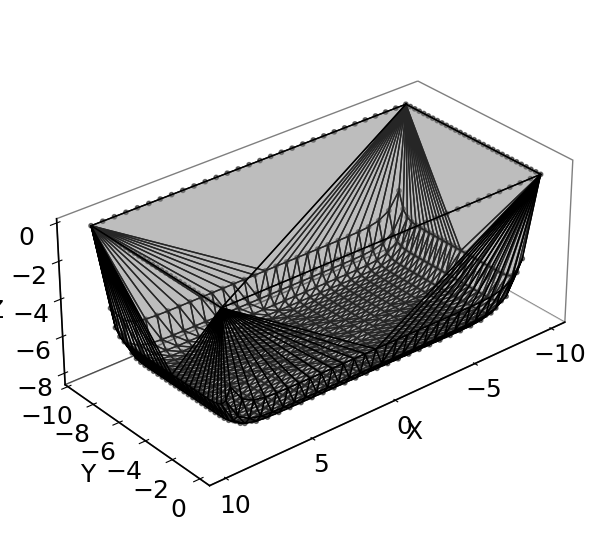

In [254]:
design = lib_RFdesign.ConvexBackshort(model_path=model_paths[0])
convex_backshort = design.genBackshort()
design.plotConvex3D(convex_backshort)

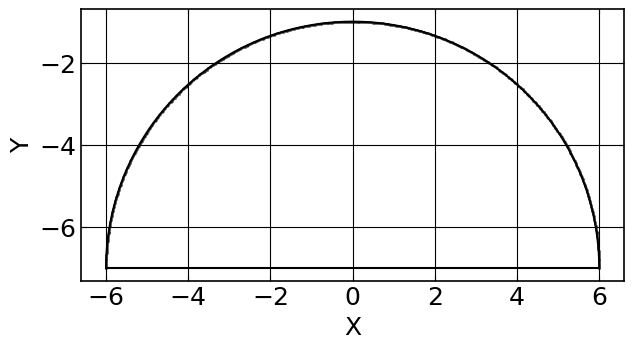

In [255]:
design = lib_RFdesign.ConvexFinshape(model_path=model_paths[1])
convex_finshpe = design.genFinshape()
design.plotProfile2D(convex_finshpe)

In [256]:
RESULTS_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_output"]))
TEMP_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"]))

In [257]:
def getResult(input_params, param_names, temp_hfss_path, result_file_path):
    df_temp = pd.read_csv(temp_hfss_path)
    header_flag = not os.path.exists(result_file_path)
    
    try:
        s11_value = df_temp.iloc[-1, -1]
        result_row = dict(zip(param_names, input_params))
        result_row["S11"] = s11_value

        df_result = pd.DataFrame([result_row]) # jissainiha kokowo w/o csv de all data fame demo OK
        df_result.to_csv(result_file_path, mode='a', header=header_flag, index=False) # append master file

        try:
            os.remove(temp_hfss_path)
        except OSError:
            pass
        return True
        
    
    except Exception as e:
        print(f"[Error][getResult] Failed to process result: {e}")
        return False

In [258]:
# --- A. HFSS ---
def target_hfss(_config_temp, sim_id, param_names, params):
    backbone.call_subroutine(_config_temp, sim_id, param_names, params, value_fmt="{:.3f}")
    getResult(params, param_names, TEMP_FILE, RESULTS_FILE)
    df_result = pd.read_csv(RESULTS_FILE)
    return df_result.iloc[-1]['S11'] # <--- should be defined as objective param

# --- B. Synthetic Test Function ---
def target_ackley(params):
    
    # --- 2. Calculation ---
    x = np.array(params)
    n = len(params)

    arg1 = -0.2 * np.sqrt((1.0/n) * np.sum(x**2))
    arg2 = (1.0/n) * np.sum(np.cos(2. * np.pi * x))
    
    y = -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

    return y

def target_add(params):

    x = np.array(params)

    y = np.sum(params)

    return y

def target_griewank(params):
    
    x = np.array(params)
    n = len(params)

    sum_term = np.sum(x**2) / 4000.0

    indices = np.arange(1, n + 1)
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))
    
    y = 1.0 + sum_term - prod_term
    
    return y

costFunction = target_add
costFunction = target_ackley
costFunction = target_griewank
costFunction = target_hfss

# =====================================
if costFunction == target_hfss:
    cfg = app_config.hfss
elif costFunction == target_ackley:
    cfg = app_config.test
elif costFunction == target_add:
    cfg = app_config.test
elif costFunction == target_griewank:
    cfg = app_config.test


LOWER_BOUNDS = cfg.lower_bounds
UPPER_BOUNDS = cfg.upper_bounds
PARAM_NAMES = cfg.param_names
N_REPT = cfg.n_repeats
N_INIT = cfg.n_init
N_OPTM = cfg.n_simulation - cfg.n_init


In [259]:
if cfg.n_simulation <= cfg.n_init:
    raise ValueError("n_simulation must be greater than n_init.")

In [260]:
backbone._get_path_models()[0]

[WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0114023934/Backshort.step'),
 WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0114023934/Finshape.step')]

In [261]:
_config_temp = {
"n_simulation": cfg.n_simulation,
"n_repeats": cfg.n_repeats,
#"param_names": cfg.param_names[:4],
#"param_units": cfg.param_units[:4],
"WATCH_DIR": str(backbone._get_dir_run()),
"INPUT_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_input"])),
"MODEL_FILE": model_paths_str,
"RESULTS_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_output"])),
"TEMP_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"])),
}

with open(base_dir / Path("_config_HFSS.json"), 'w') as f:
        json.dump(_config_temp , f, indent=4)

print(f"Temporarily updated '{base_dir / Path("_config_HFSS.json")}' with run-specific WATCH_DIR for HFSS.")

Temporarily updated 'T:\RAkizawa\HFSS_C2WR10\src\_config_HFSS.json' with run-specific WATCH_DIR for HFSS.


In [262]:
def costFunctionWrapper(param_names, params,):

    params = np.array(params).flatten()
    sim_id = backbone._getSimulationID()
    
    y = costFunction(_config_temp, sim_id, param_names, params,)
       
    # output
    _newline = dict(zip(param_names, params))
    _newline['S11'] = y

    return y, _newline

In [263]:
# Optimizer

def optGaussianProcess(n_optm, history_data, lower_bound, upper_bound):

    current_gamma = 1.0
        
    for i in range(n_optm):
    
        df_current = pd.DataFrame(history_data)
        
        X_sample = df_current[PARAM_NAMES].values
        y_sample = df_current[['S11']].values
        
        gamma, K, Ky, Ky_inv, hyp = gp.run_gp(X_sample, y_sample, current_gamma)
        
        #x_new, x_acq = gp.getExpectedImprovement(X_sample, y_sample, Ky_inv, gamma, lower_bound, upper_bound, dims=len(upper_bound))
        x_new, x_acq = gp.optAcquisition(lib_gp.lower_confidence_bound, X_sample, y_sample, Ky_inv, gamma, lower_bound, upper_bound, {'kappa': 2.0})
        #x_new, x_acq = gp.optAcquisition(lib_gp.expected_improvement, X_sample, y_sample, Ky_inv, gamma, lower_bound, upper_bound, {'xi': 0.01})

        y_new, _newline = costFunctionWrapper(PARAM_NAMES, x_new)

        _newline['Acq'] = x_acq
        _newline['gamma'] = gamma
        history_data.append(_newline)

        print(f"{i+1:<5} | {y_new.item():.6f}   | {gamma:.4f}   | {x_acq:.4f}   | [{x_new[0]:.6f}, {x_new[1]:.6f}]")

        current_gamma = gamma


Starting GP Repeat 1/2

--- Generating 15 Initial Samples ---
 > Using 3 known points. Generating 12 LHS points.
[[-9.04        2.42        2.22        3.29        2.        ]
 [-8.77        2.59        2.22        3.24        2.        ]
 [-8.58        2.68        2.21        3.22        1.95      ]
 [-5.44804582  2.76393248  7.5841564   4.31380638  1.89540871]
 [-3.14353741  2.5937973   2.8862236   4.71612753  5.67271351]
 [-5.14176738  3.11596267  3.00703472  5.4820458   3.6869031 ]
 [-3.424358    4.30169752  5.53447701  7.75391649  2.41374388]
 [-6.49415134  2.30760763  7.41422884  2.32943624  3.24727804]
 [-9.03710583  3.34575722  4.55199269  3.92238373  4.80424351]
 [-7.69255251  1.17474212  5.38462228  6.30113127  4.49865874]
 [-9.83736342  1.98660575  2.33035971  7.06137775  1.66454083]
 [-2.52101558  4.4367295   4.39095266  5.84246052  5.23702775]
 [-7.3040777   1.53813965  6.29404344  2.50711873  2.94200595]
 [-4.5947686   4.67152802  6.72871154  6.96882525  1.18012164]
 [-8

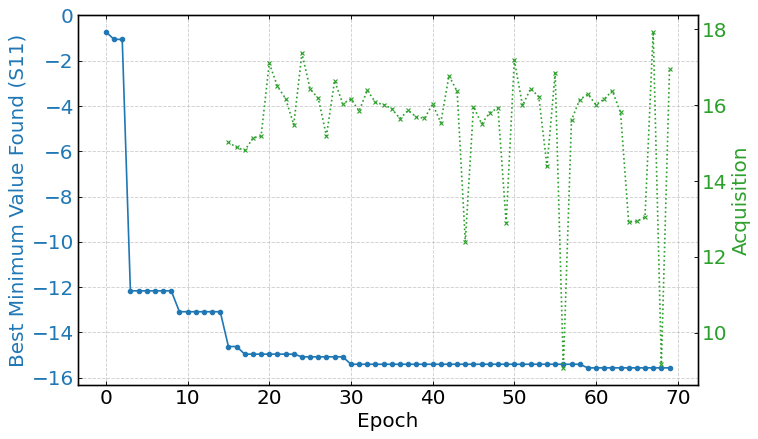


Starting GP Repeat 2/2

--- Generating 15 Initial Samples ---
 > Using 3 known points. Generating 12 LHS points.
[[-9.04        2.42        2.22        3.29        2.        ]
 [-8.77        2.59        2.22        3.24        2.        ]
 [-8.58        2.68        2.21        3.22        1.95      ]
 [-8.09277322  2.25074538  7.21147754  2.7479736   4.10640013]
 [-5.4771037   4.60504278  4.0413016   6.25732228  2.55601556]
 [-3.85669567  2.44448693  3.57926798  4.04827114  4.73094662]
 [-5.04436888  1.6764229   5.33191442  3.18862983  2.03872902]
 [-3.21353515  3.20691202  7.61302232  6.53138166  2.81446975]
 [-7.67771512  1.1352777   4.78627402  7.31130324  3.83345814]
 [-6.4142761   2.73500454  2.23752811  3.750809    3.39982974]
 [-9.25965206  4.89007799  6.61069754  2.32643049  5.23680067]
 [-9.38888341  1.40579637  2.82427572  7.75511127  1.30761759]
 [-6.68233174  3.84770392  3.27069399  5.28201727  1.68852032]
 [-4.66225554  4.12712381  6.14560181  4.99130291  5.73036505]
 [-2

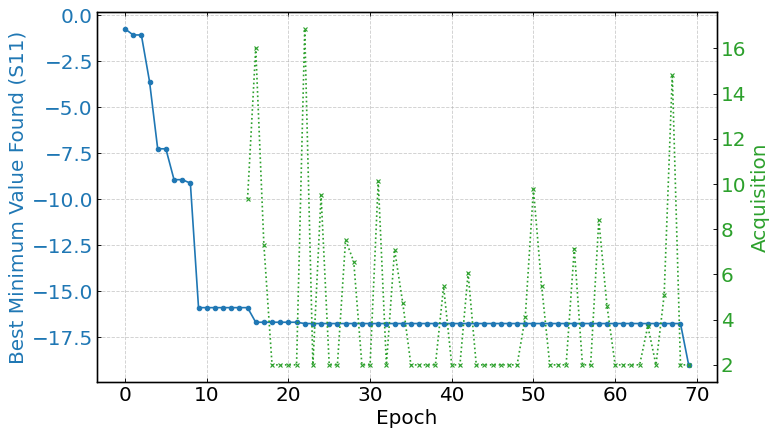

In [ ]:
my_best_input = [
    [-9.04, 2.42, 2.22, 3.29, 2.00,],
    [-8.77, 2.59, 2.22, 3.24, 2.00,],
    [-8.58, 2.68, 2.21, 3.22, 1.95,],
]
my_best_input = [
    [-9.04, 2.42, 2.22,],
    [-8.77, 2.59, 2.22,],
    [-8.58, 2.68, 2.21,],
]
backbone.all_in_bounds(my_best_input, LOWER_BOUNDS, UPPER_BOUNDS)


try:
    
    # --- Outer loop for each independent repeat ---
    for r in range(N_REPT):
        backbone.printn(f"Starting GP Repeat {r + 1}/{N_REPT}")
        history_data = []
        
        # -------------------- initial simulation --------------------------------
        backbone.printn(f"--- Generating {N_INIT} Initial Samples ---")
        
        
        #X_initial = backbone.LHSsampler(dims = cfg.n_params, nums=N_INIT, lower_bounds=LOWER_BOUNDS, upper_bounds=UPPER_BOUNDS)
        X_initial = backbone.LHSsampler(dims = cfg.n_params, nums=N_INIT, lower_bounds=LOWER_BOUNDS, upper_bounds=UPPER_BOUNDS, known_points=my_best_input)
        print(X_initial)
        
        print(f"{'Iter':<5} | {'New y':<10} | {'Gamma':<8} | {'x_acq':<8} | {'New x'}")        
        for i in range(N_INIT):
            params = X_initial[i]
            y_new, _newline = costFunctionWrapper(PARAM_NAMES, params,)
            history_data.append(_newline)


        # -------------------- GP --------------------------------
        optGaussianProcess(N_OPTM, history_data, LOWER_BOUNDS, UPPER_BOUNDS)

        # ==============================================================================
        df_final = pd.DataFrame(history_data)
        X_train = df_final[PARAM_NAMES].values
        y_train = df_final['S11'].values

        best_idx_final = np.argmin(y_train)
        print("-" * 75)
        print(f"Optimization Finished.")
        print(f"Global Best Found: y = {y_train[best_idx_final]:.6f}")
        
        best_x_str = np.array2string(X_train[best_idx_final], precision=4, separator=', ')
        print(f"At location: x = {best_x_str}")
        
        # --- After each repeat, archive results and save plot data ---
        df_output = backbone._genOutputDataFrame(df_final)
        
        # save
        backbone._addNewDatasetToHDF(df_output, "output", f"repeat_{r+1}")
        
        # --- 5a. Visualize learning curve of the final model ---
        plot.plot_learning_curve(df_output)
                
finally:
    json_file = base_dir / Path("_config_HFSS.json")
    json_file.unlink(missing_ok=True) # delite the json file
    if backbone.h5f:
        backbone.h5f.close()